In [10]:
# https://www.kaggle.com/crowdflower/twitter-airline-sentiment
!wget -nc https://lazyprogrammer.me/course_files/AirlineTweets.csv

File ‘AirlineTweets.csv’ already there; not retrieving.



In [11]:
import numpy as np
import pandas as pd
import seaborn as sn
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam

In [12]:
np.random.seed(0)
tf.random.set_seed(0)

In [13]:
df = pd.read_csv('AirlineTweets.csv')

In [14]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [16]:
df = df[['airline_sentiment', 'text']]

<Axes: >

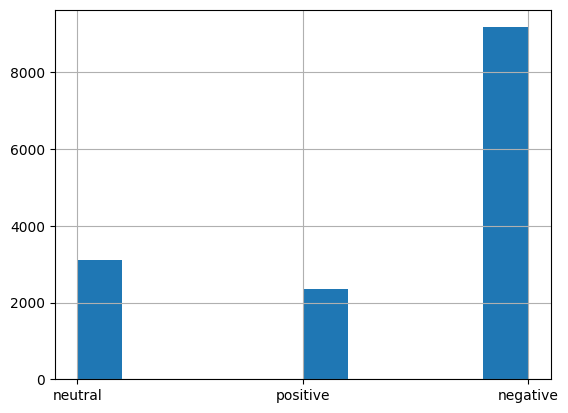

In [19]:
df['airline_sentiment'].hist()
# the data set is imbalanced

In [22]:
df = df[df['airline_sentiment'] != 'neutral'].copy()
# filter out neutral column

In [24]:
target_map = {'positive':1, 'negative':0}
df['target'] = df['airline_sentiment'].map(target_map)

In [25]:
df.head()

,airline_sentiment,text,target
1,positive,@VirginAmerica plus you've added commercials t...,1
3,negative,@VirginAmerica it's really aggressive to blast...,0
4,negative,@VirginAmerica and it's a really big bad thing...,0
5,negative,@VirginAmerica seriously would pay $30 a fligh...,0
6,positive,"@VirginAmerica yes, nearly every time I fly VX...",1


In [26]:
df_train,df_test = train_test_split(df, random_state = 42 )

In [27]:
vectorizer = TfidfVectorizer(max_features=2000)
X_train = vectorizer.fit_transform(df_train['text'])
X_test = vectorizer.transform(df_test['text'])

TensorFlow doesn't know how to deal with sparse matrix

In [28]:
# data must not be sparse matrix before passing into tensorflow
X_train = X_train.toarray()
X_test = X_test.toarray()

In [29]:
Y_train = df_train['target']
Y_test = df_test['target']

In [30]:
# input dimensions : # columns in X_train
D = X_train.shape[1]

In [32]:
#build model
i = Input(shape= (D,))
x = Dense(1)(i) # sigmoid included in loss
model = Model(i,x)

In [33]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         2,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,001 (7.82 KB)

 Trainable params: 2,001 (7.82 KB)

 Non-trainable params: 0 (0.00 B)

2000 inputs so 2000 weights -> 2000 parameters
\+ 1 bias weight = 2001 parameters

In [34]:
model.compile(
  loss=BinaryCrossentropy(from_logits=True),
  optimizer=Adam(learning_rate=0.01),
  metrics=['accuracy']
)

In [35]:
r = model.fit(
  X_train, Y_train,
  validation_data=(X_test, Y_test),
  epochs=40,
  batch_size=128,
)

Epoch 1/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7990 - loss: 0.5710 - val_accuracy: 0.8049 - val_loss: 0.3969
Epoch 2/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8009 - loss: 0.3815 - val_accuracy: 0.8219 - val_loss: 0.3391
Epoch 3/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8204 - loss: 0.3239 - val_accuracy: 0.8427 - val_loss: 0.3021
Epoch 4/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8467 - loss: 0.2843 - val_accuracy: 0.8600 - val_loss: 0.2764
Epoch 5/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8650 - loss: 0.2556 - val_accuracy: 0.8780 - val_loss: 0.2579
Epoch 6/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8813 - loss: 0.2337 - val_accuracy: 0.8895 - val_loss: 0.2440
Epoch 7/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8955 - loss: 0.2165 - val_accuracy: 0.8995 - val_loss: 0.2333
Epoch 8/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9054 - loss: 0.2026 - val_accuracy: 0.9047 - val_loss:

ML algorithms always behave better for training set

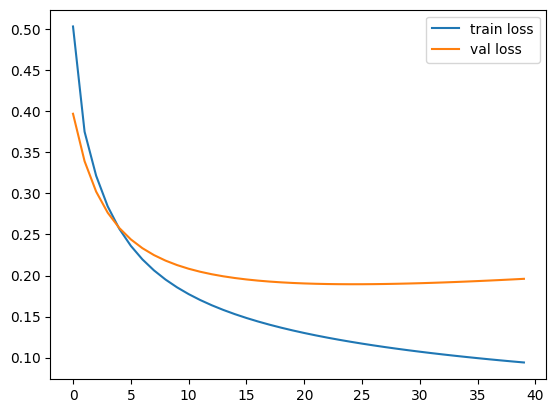

In [38]:
# Plot loss per iteration or per epoch
# val stands for validation
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend();

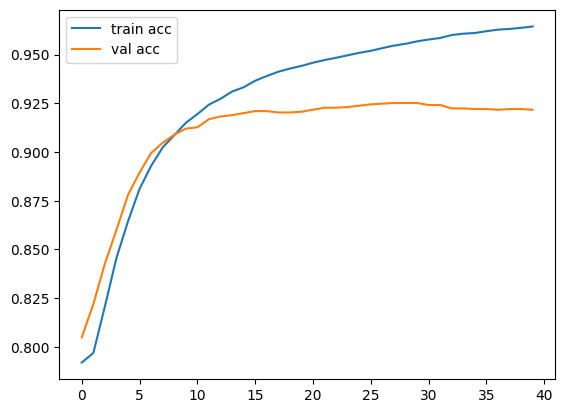

In [39]:
# Plot accuracy per iteration
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend();

In [40]:
P_train = ((model.predict(X_train) > 0) * 1.0).flatten()
P_test = ((model.predict(X_test) > 0) * 1.0).flatten()
# flatten makes P_train and P_test one dimensional array

271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [46]:
cm = confusion_matrix(Y_train, P_train, normalize='true')
cm

array([[0.99051787, 0.00948213],
       [0.09722222, 0.90277778]])

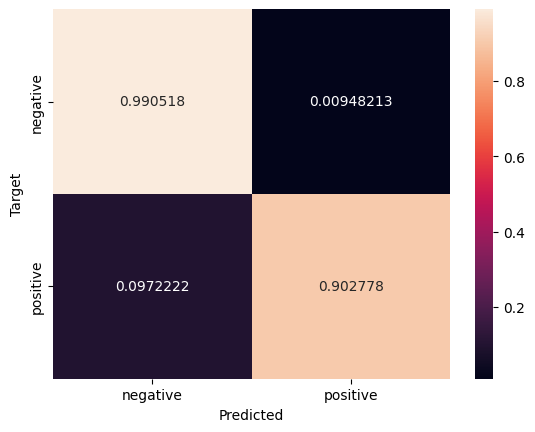

In [47]:
# Scikit-Learn is transitioning to V1 but it's not available on Colab
# The changes modify how confusion matrices are plotted
def plot_cm(cm):
  classes = ['negative', 'positive']
  df_cm = pd.DataFrame(cm, index=classes, columns=classes)
  ax = sn.heatmap(df_cm, annot=True, fmt='g')
  ax.set_xlabel("Predicted")
  ax.set_ylabel("Target")

plot_cm(cm)

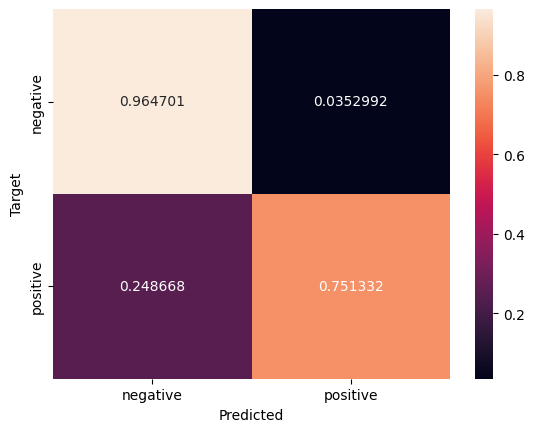

In [48]:
cm_test = confusion_matrix(Y_test, P_test, normalize='true')
plot_cm(cm_test)

since we have an imbalanced class we try AUC

In [50]:
Pr_train = model.predict(X_train)
Pr_test = model.predict(X_test)
print("Train AUC:", roc_auc_score(Y_train, Pr_train))
print("Test AUC:", roc_auc_score(Y_test, Pr_test))

271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Train AUC: 0.9948838641705163
Test AUC: 0.9535038066321111


In [51]:
print("Train F1:", f1_score(Y_train, P_train))
print("Test F1:", f1_score(Y_test, P_test))

Train F1: 0.9312320916905444
Test F1: 0.7921348314606742


In [54]:
model.layers
# check the layers attributes of the model

[<InputLayer name=input_layer_1, built=True>, <Dense name=dense_1, built=True>]

In [55]:
model.layers[1].get_weights()
# to get the weight of the dense layer

[array([[-3.6196585],
        [ 3.357185 ],
        [-1.6327785],
        ...,
        [ 1.9080989],
        [ 1.4609289],
        [-2.856312 ]], dtype=float32),
 array([-0.23175056], dtype=float32)]

In [56]:
w = model.layers[1].get_weights()[0]

In [57]:
word_index_map = vectorizer.vocabulary_
word_index_map

{'jetblue': np.int64(972),
 'thanks': np.int64(1724),
 'for': np.int64(749),
 'having': np.int64(851),
 'us': np.int64(1860),
 'hang': np.int64(834),
 'out': np.int64(1263),
 'at': np.int64(193),
 'tampa': np.int64(1706),
 'airport': np.int64(121),
 'forever': np.int64(752),
 'today': np.int64(1764),
 'it': np.int64(963),
 'really': np.int64(1420),
 'been': np.int64(239),
 'an': np.int64(146),
 'awesome': np.int64(213),
 'experience': np.int64(650),
 'americanair': np.int64(142),
 'was': np.int64(1897),
 'told': np.int64(1767),
 'you': np.int64(1992),
 'could': np.int64(446),
 'only': np.int64(1246),
 'refund': np.int64(1434),
 'me': np.int64(1109),
 'the': np.int64(1728),
 'cost': np.int64(442),
 'of': np.int64(1225),
 'my': np.int64(1180),
 'original': np.int64(1255),
 'return': np.int64(1476),
 'flight': np.int64(722),
 'note': np.int64(1212),
 'had': np.int64(824),
 'booked': np.int64(268),
 'more': np.int64(1165),
 'expensive': np.int64(649),
 'everyone': np.int64(631),
 'else': n

In [58]:
# let's look at the weights for each word
# try it with different threshold values!
threshold = 2

print("Most positive words:")
word_weight_tuples = []
for word, index in word_index_map.items():
    weight = w[index, 0]
    if weight > threshold:
        word_weight_tuples.append((word, weight))

word_weight_tuples = sorted(word_weight_tuples, key=lambda x: -x[1])
for i in range(10):
  word, weight = word_weight_tuples[i]
  print(word, weight)

Most positive words:
thank 9.767228
thanks 9.426604
worries 8.592701
great 8.098712
love 7.4512987
awesome 7.4016275
excellent 7.1591873
kudos 6.797155
amazing 6.453017
best 6.1792974


In [59]:
print("Most negative words:")
word_weight_tuples = []
for word, index in word_index_map.items():
    weight = w[index, 0]
    if weight < -threshold:
        word_weight_tuples.append((word, weight))

word_weight_tuples = sorted(word_weight_tuples, key=lambda x: x[1])
for i in range(10):
  word, weight = word_weight_tuples[i]
  print(word, weight)

Most negative words:
worst -9.313586
paid -7.9823856
not -7.8223
rude -7.6416717
nothing -6.9640512
disappointed -6.960179
hung -6.8071756
website -6.772041
instead -6.5296955
failed -6.207999
